# Analisis datos encontrados por medio de grupos

## Carga de librerias
Empezamos cargando librerias.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline


## Carga y formateo
- Cargo los datos 
- Creo grupos interesantes apartando la hora y los minutos para pasar al algoritmo si crea que no inutilies o causan problemas elimino y pruebo otros

In [12]:
df1 = pd.read_csv('completo_direccion_1.csv')
df2 = pd.read_csv('completo_direccion_2.csv')
df3 = pd.read_csv('completo_direccion_3.csv')
df4 = pd.read_csv('completo_direccion_4.csv')

features = ['Total_Vehiculos', 'Tiempo_Medio_s', 'Ocupacion_Espacial_%']

X1 = df1[features]
X2 = df2[features]
X3 = df3[features]
X4 = df4[features]


## Escalado de Datos
Se preparan los datos y se colocan todas las variables en una escala para su procesado

In [13]:
scaler = StandardScaler() 
X_scaled1 = scaler.fit_transform(X1)
X_scaled2 = scaler.fit_transform(X2)
X_scaled3 = scaler.fit_transform(X3)
X_scaled4 = scaler.fit_transform(X4)

X_scaled_df1 = pd.DataFrame(X_scaled1, columns=features)
X_scaled_df2 = pd.DataFrame(X_scaled2, columns=features)
X_scaled_df3 = pd.DataFrame(X_scaled3, columns=features)
X_scaled_df4 = pd.DataFrame(X_scaled4, columns=features)


En este primer grafico se puede denotar que donde mejor se diferencian los grupos es con 3 clusters.

## Entrenamiento modelo
Aca es donde sucede la magiaaaa!!

In [14]:
k = 3

kmeans1 = KMeans(n_clusters= k ,random_state=42, n_init=20)
kmeans2 = KMeans(n_clusters= k ,random_state=42, n_init=20)
kmeans3 = KMeans(n_clusters= k ,random_state=42, n_init=20)
kmeans4 = KMeans(n_clusters= k ,random_state=42, n_init=20)
kmeans5 = KMeans(n_clusters= k ,random_state=42, n_init=20)
kmeans1.fit(X_scaled_df1)
kmeans2.fit(X_scaled_df2)
kmeans3.fit(X_scaled_df3)
kmeans4.fit(X_scaled_df4)

df1['cluster'] = kmeans1.labels_
df2['cluster'] = kmeans2.labels_
df3['cluster'] = kmeans3.labels_
df4['cluster'] = kmeans4.labels_


Okey no interpreto nada con los datos en crudo, vamos a añadir graficos 

## Representacion mediante graficos
Esto ayuda a entender en su totalidad los datos

1. Muestro los centroides


1. PERFILES DE TRÁFICO (HEATMAPS CORREGIDOS)


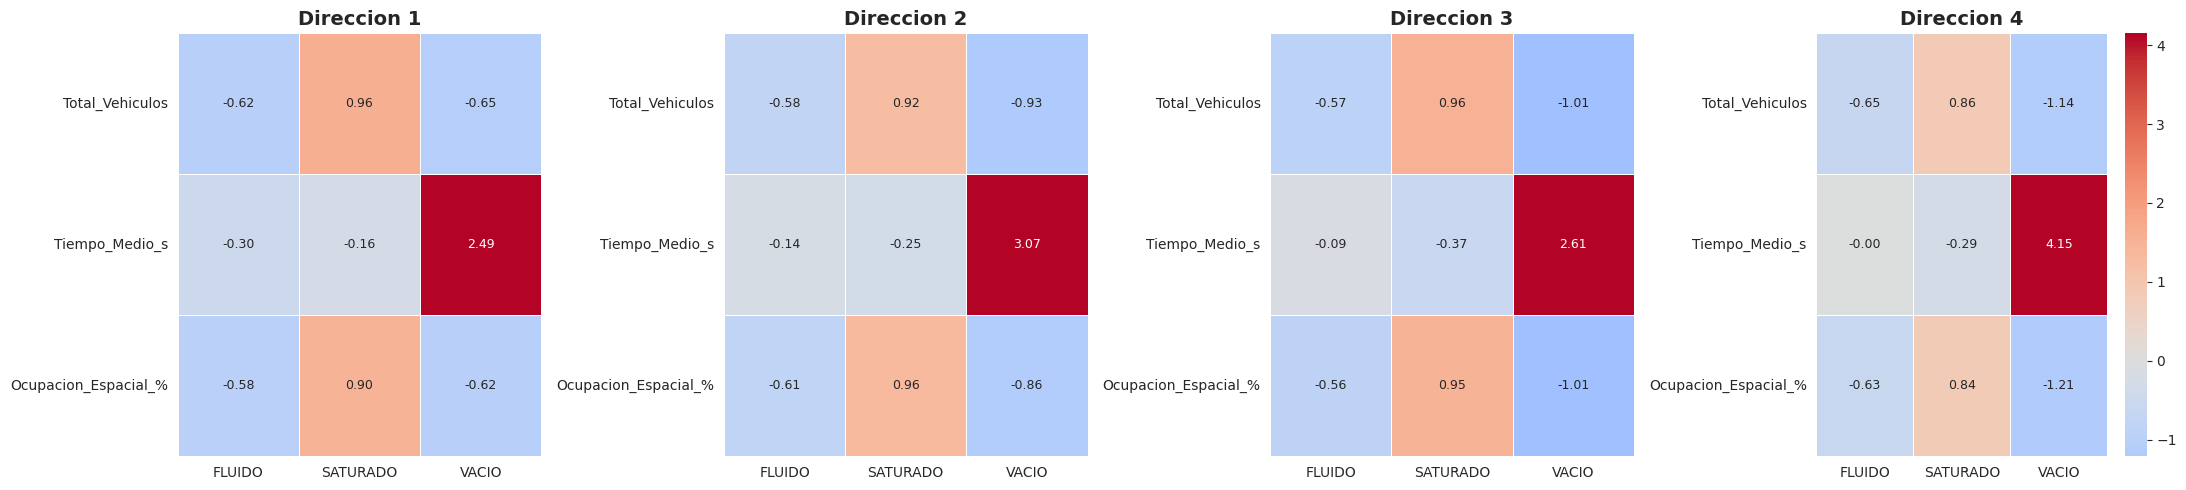


2. DISTRIBUCIÓN DE CLUSTERS (PCA UNIFICADO)


/home/adrian/.pyenv/versions/tesisvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/adrian/.pyenv/versions/tesisvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/adrian/.pyenv/versions/tesisvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/adrian/.pyenv/versions/tesisvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


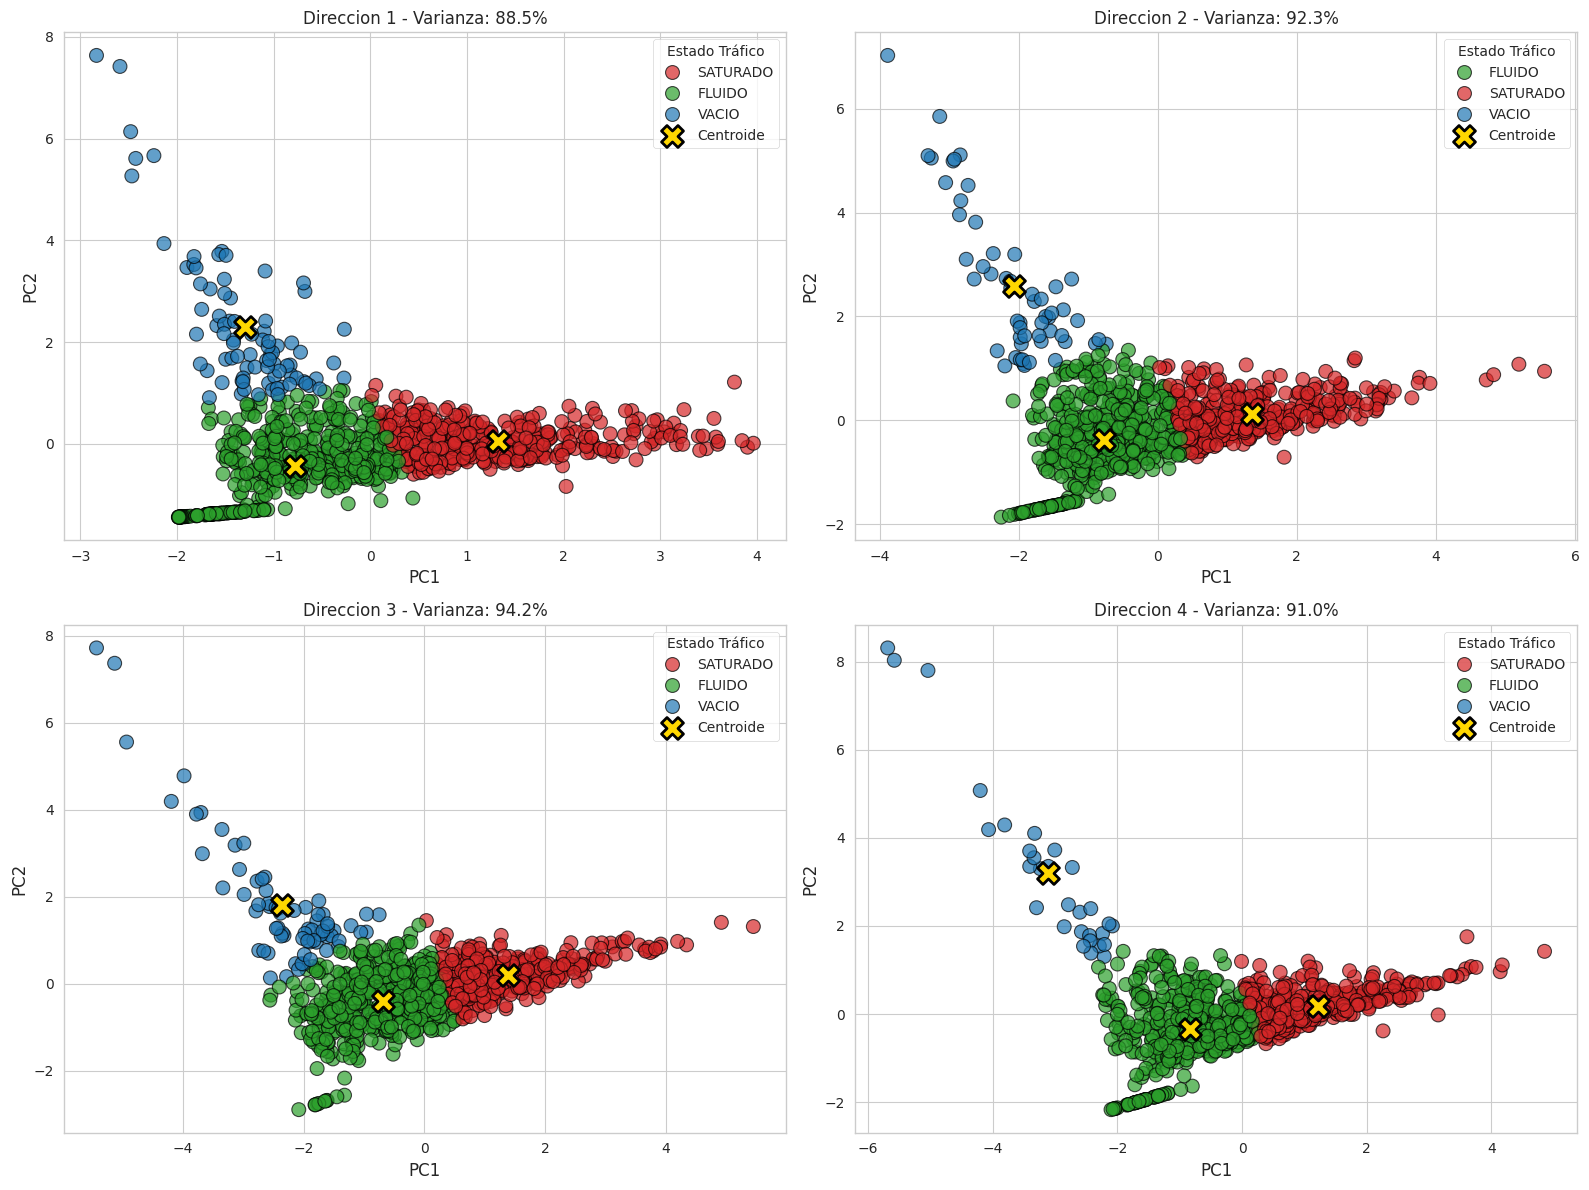


3. PORCENTAJE DE TIEMPO EN CADA ESTADO


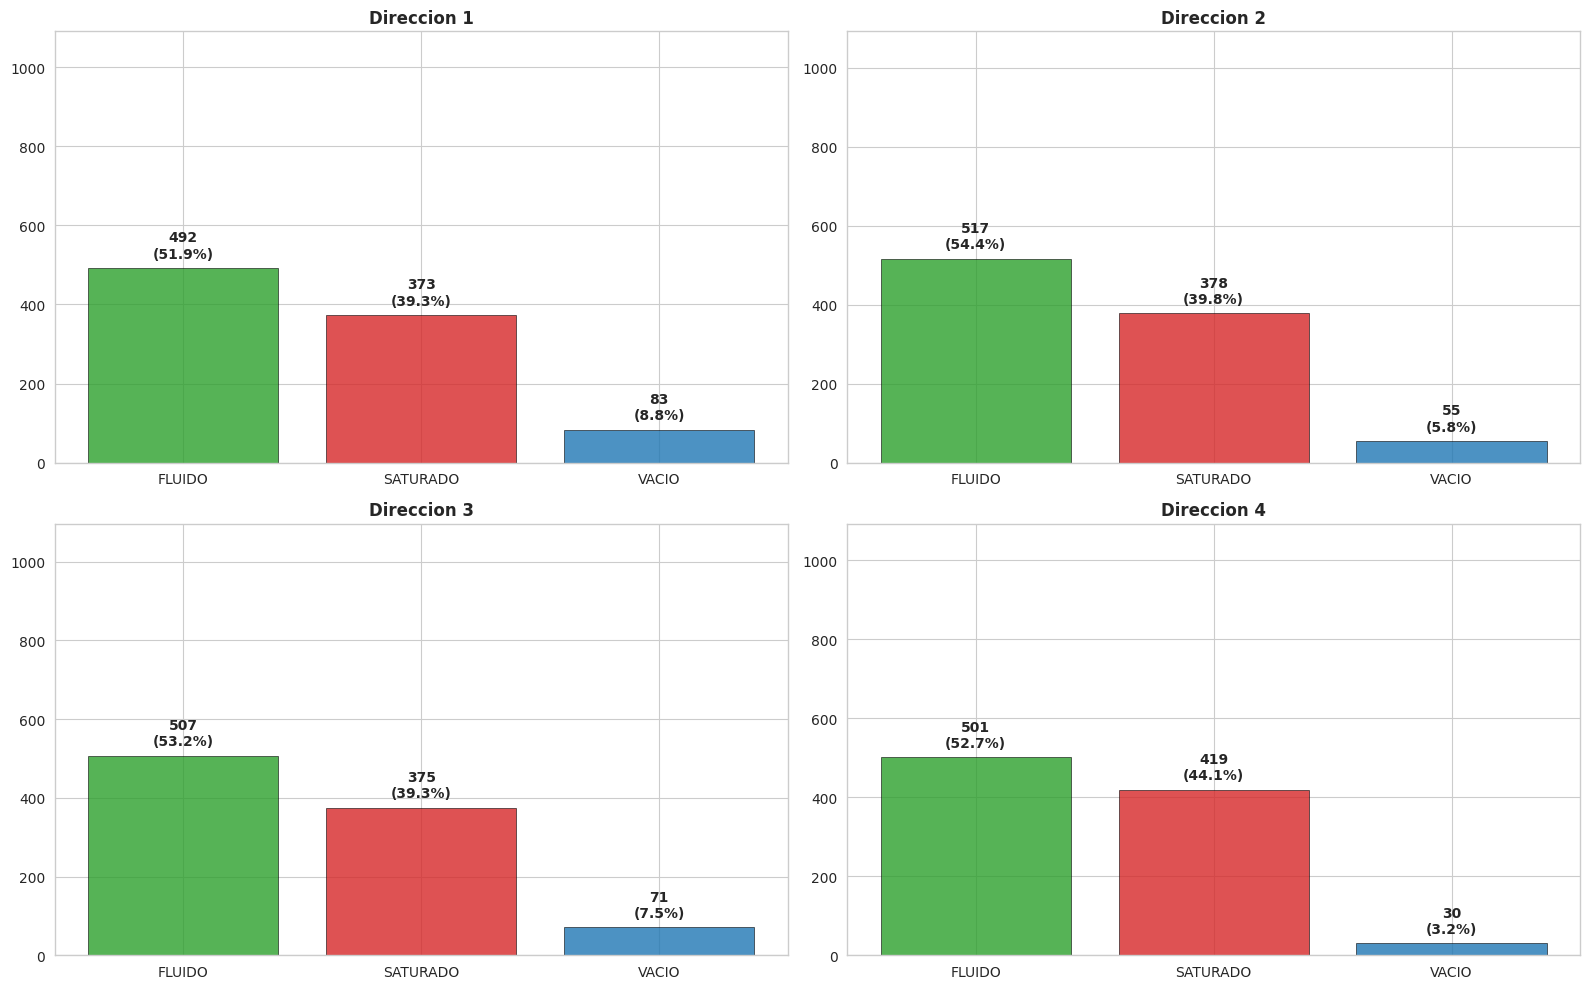

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

datasets = [
    {'name': 'Direccion 1', 'X_scaled': X_scaled_df1, 'kmeans': kmeans1, 'df': df1},
    {'name': 'Direccion 2', 'X_scaled': X_scaled_df2, 'kmeans': kmeans2, 'df': df2},
    {'name': 'Direccion 3', 'X_scaled': X_scaled_df3, 'kmeans': kmeans3, 'df': df3},
    {'name': 'Direccion 4', 'X_scaled': X_scaled_df4, 'kmeans': kmeans4, 'df': df4},
    
]


COLOR_MAP = {
    'SATURADO': '#d62728',  # Rojo
    'FLUIDO':   '#2ca02c',  # Verde
    'VACIO':    '#1f77b4'   # Azul
}

def get_semantic_labels(kmeans_model, feature_names):
    """
    Analiza los centroides y asigna un nombre lógico (Saturado, Fluido, Vacio)
    basado en las reglas de negocio de la tesis.
    """
    centroids = kmeans_model.cluster_centers_
    labels_map = {}
    
    idx_vehiculos = 0 
    idx_tiempo = 1    
    
    for cluster_id, centroid in enumerate(centroids):
        val_vehiculos = centroid[idx_vehiculos]
        val_tiempo = centroid[idx_tiempo]
        
        if val_tiempo > 1.5:
            labels_map[cluster_id] = 'VACIO'
        elif val_vehiculos > 0.2:
            labels_map[cluster_id] = 'SATURADO'
        else:
            labels_map[cluster_id] = 'FLUIDO'
            
    return labels_map

for data in datasets:
    mapping = get_semantic_labels(data['kmeans'], data['X_scaled'].columns)
    data['mapping'] = mapping
    
    labels_series = pd.Series(data['kmeans'].labels_).map(mapping)
    data['X_scaled'] = data['X_scaled'].copy() # Evitar warning
    data['X_scaled']['Label'] = labels_series.values

print("\n" + "="*80)
print("1. PERFILES DE TRÁFICO (HEATMAPS CORREGIDOS)")
print("="*80)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for idx, data in enumerate(datasets):
    df_temp = data['X_scaled'].groupby('Label').mean()
    
    orden_deseado = [l for l in ['FLUIDO', 'SATURADO', 'VACIO'] if l in df_temp.index]
    df_temp = df_temp.reindex(orden_deseado)
    
    sns.heatmap(
        df_temp.T,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",      # más suave y profesional
        center=0,
        linewidths=0.5,       # separa celdas sin rigidez
        linecolor="white",
        annot_kws={"size": 9},# texto más chico
        cbar=(idx == 3),
        ax=axes[idx]
    )

    axes[idx].set_title(f'{data["name"]}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('')
    
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("2. DISTRIBUCIÓN DE CLUSTERS (PCA UNIFICADO)")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, data in enumerate(datasets):
    pca = PCA(n_components=2)
    cols_num = [c for c in data['X_scaled'].columns if c != 'Label']
    X_pca = pca.fit_transform(data['X_scaled'][cols_num])
    
    pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    pca_df['Estado'] = data['X_scaled']['Label'].values
    
    sns.scatterplot(
        data=pca_df,
        x='PC1', y='PC2',
        hue='Estado',
     
        palette=COLOR_MAP, # ¡Aquí forzamos los colores correctos!
        s=100,
        alpha=0.7,
        ax=axes[idx],
        edgecolor='black'
    )
    
    centroids_pca = pca.transform(data['kmeans'].cluster_centers_)
    axes[idx].scatter(
        centroids_pca[:, 0], centroids_pca[:, 1],
        c='gold', marker='X', s=250, edgecolors='black', linewidth=2,
        label='Centroide', zorder=5
    )
    
    axes[idx].set_title(f'{data["name"]} - Varianza: {pca.explained_variance_ratio_.sum():.1%}', fontsize=12)
    axes[idx].legend(loc='upper right', title='Estado Tráfico')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("3. PORCENTAJE DE TIEMPO EN CADA ESTADO")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, data in enumerate(datasets):
    counts = data['X_scaled']['Label'].value_counts()
    
    orden = [l for l in ['FLUIDO', 'SATURADO', 'VACIO'] if l in counts.index]
    colores = [COLOR_MAP[l] for l in orden]
    
    counts = counts.reindex(orden)
    
    bars = axes[idx].bar(
        x=counts.index,
        height=counts.values,
        color=colores,
        edgecolor='black',
        alpha=0.8
    )
    
    total = sum(counts.values)
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(
            bar.get_x() + bar.get_width()/2., height + (total*0.02),
            f'{height}\n({height/total:.1%})',
            ha='center', va='bottom', fontweight='bold'
        )
        
    axes[idx].set_title(f'{data["name"]}', fontsize=12, fontweight='bold')
    axes[idx].set_ylim(0, total * 1.15) # Margen arriba

plt.tight_layout()
plt.show()